---
skip_execution: true
---

# 1. Regularized linear RTO

## Table of Contents

## Learning objectives


**Imports**

In [1]:
# Load modules and set-up test problem
import sys
# sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

import cuqi
from cuqi.testproblem import Deconvolution1D
from cuqi.distribution import Gaussian, JointDistribution, GMRF
from cuqi.implicitprior import RegularizedGaussian
from cuqi.sampler import RegularizedLinearRTO, MH, LinearRTO
from cuqi.geometry import StepExpansion

# Set seed
np.random.seed(24601)


## Set-up the problem

Set up the true parameter, the forward model (convolution), and the data: 

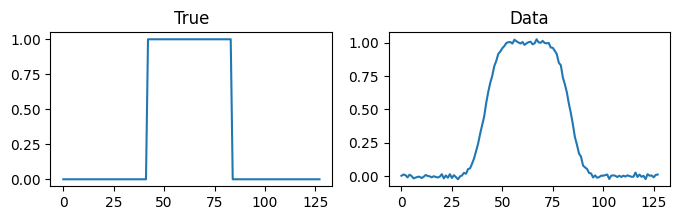

In [2]:
n = 128

x_true = np.zeros(n)
x_true[int(n/3):2*int(n/3)] += 1

A, y_data, info = Deconvolution1D(dim=n, phantom=x_true, PSF_param = 5).get_components()

plt.figure(figsize = (8,2))
plt.subplot(1,2,1)
info.exactSolution.plot()
plt.title("True")

plt.subplot(1,2,2)
y_data.plot()
plt.title("Data")

plt.savefig("figures/staircase/stairs_data.pdf")

## BP set up and solution: unconstrained

Warning (GMRF): Periodic and Neumann boundary conditions are experimental. Sampling using LinearRTO may not produce fully accurate results.


Sample: 100%|██████████| 500/500 [00:07<00:00, 67.98it/s, acc rate: 100.00%]


Plotting 5 randomly selected samples


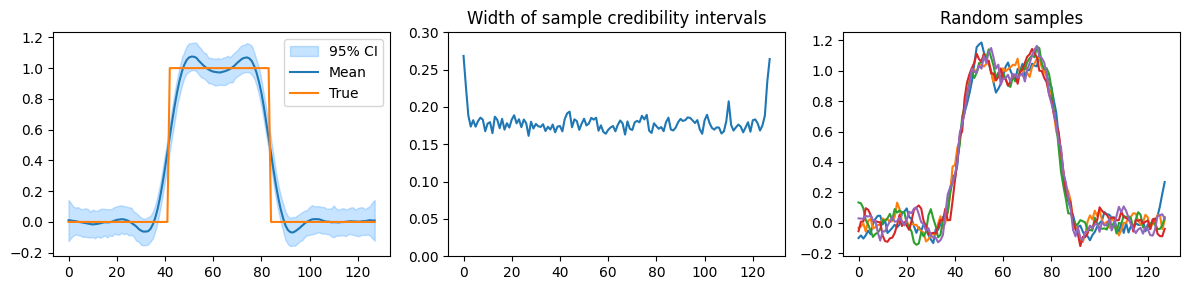

In [3]:
# General sampling parameters
num_samples = 500
num_burnin = 0
thinning = 1

# Construct posterior
x = GMRF(np.zeros(n), prec = 500, bc_type='neumann')
y  = Gaussian(A@x, 0.001)
joint = JointDistribution(x, y)
posterior = joint(y=y_data)

# Sample
np.random.seed(24601)
sampler = LinearRTO(posterior) 
sampler.sample(num_samples)
samples = sampler.get_samples().burnthin(num_burnin, thinning)

# Create figure
plt.figure(figsize = (12,3))
plt.subplot(1,3,1)
samples.plot_ci()
plt.plot(info.exactSolution)
plt.legend([ "95% CI", "Mean", "True"])

plt.subplot(1,3,2)
samples.plot_ci_width()
plt.ylim((0, 0.3))

plt.subplot(1,3,3)
samples.plot()
plt.title("Random samples")

plt.tight_layout()
plt.savefig("figures/staircase/stairs_results_gaussian.pdf")

## BP set up and solution: TV regularized

In [4]:
# General sampling parameters
num_samples = 100
num_burnin = 0
thinning = 1

# Construct posterior
x = RegularizedGaussian(np.zeros(n), prec = 10, regularization='tv',strength=40)
y = Gaussian(A@x, 0.001)
posterior = JointDistribution(x, y)(y=y_data)

# Sample
np.random.seed(24601)
sampler = RegularizedLinearRTO(posterior,
                                    maxit=100)#,
                                    #penalty_parameter = 1000) 
sampler.sample(num_samples + num_burnin)
samples = sampler.get_samples().burnthin(num_burnin, thinning)

Sample: 100%|██████████| 100/100 [01:03<00:00,  1.57it/s, acc rate: 100.00%]


Plotting 5 randomly selected samples


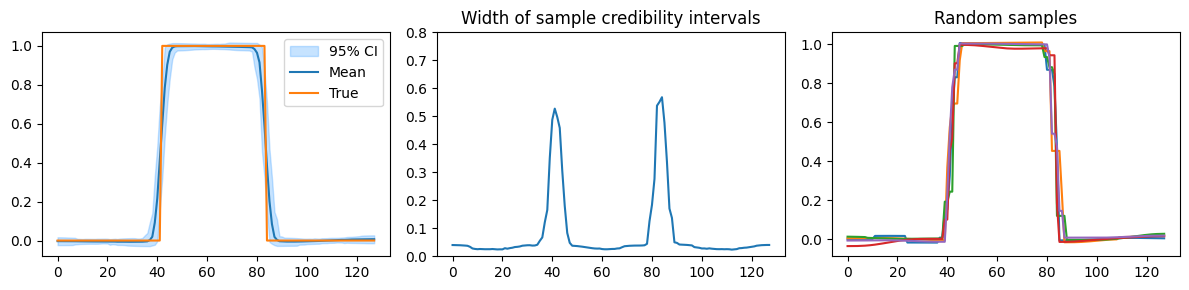

In [5]:
# Create figure
plt.figure(figsize = (12,3))
plt.subplot(1,3,1)
samples.plot_ci()
plt.plot(info.exactSolution)
plt.legend([ "95% CI", "Mean", "True"])

plt.subplot(1,3,2)
samples.plot_ci_width()
plt.ylim((0, 0.8))

plt.subplot(1,3,3)
samples.plot()
plt.title("Random samples")

plt.tight_layout()
plt.savefig("figures/staircase/stairs_results_gaussian_tv.pdf")

## BP set up and solution: TV regularized + non-negativity constraint

In [10]:
# General sampling parameters
num_samples = 100
num_burnin = 0
thinning = 1

# Construct posterior
x = RegularizedGaussian(np.zeros(n), prec = 10, regularization='tv',strength=40, constraint="nonnegativity")
y = Gaussian(A@x, 0.001)
posterior = JointDistribution(x, y)(y=y_data)

# Sample
np.random.seed(24601)
sampler = RegularizedLinearRTO(posterior,
                                    maxit=400)#,
                                    #penalty_parameter = 1000) 
sampler.sample(num_samples + num_burnin)
samples = sampler.get_samples().burnthin(num_burnin, thinning)

Sample: 100%|██████████| 100/100 [05:07<00:00,  3.08s/it, acc rate: 100.00%]


Plotting 5 randomly selected samples


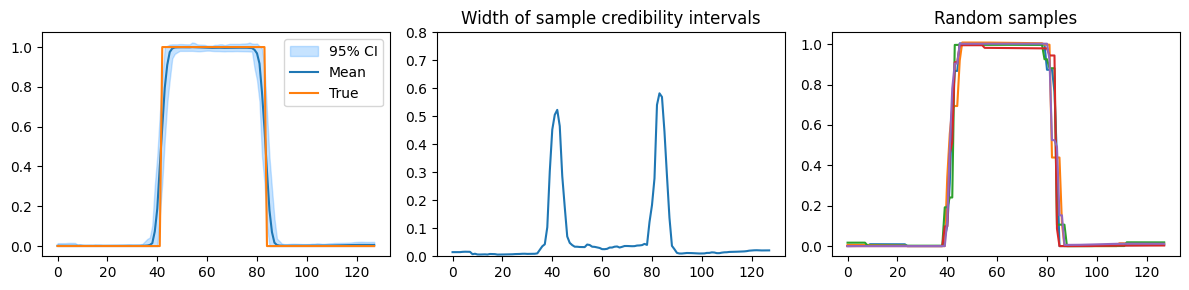

In [11]:
# Create figure
plt.figure(figsize = (12,3))
plt.subplot(1,3,1)
samples.plot_ci()
plt.plot(info.exactSolution)
plt.legend([ "95% CI", "Mean", "True"])

plt.subplot(1,3,2)
samples.plot_ci_width()
plt.ylim((0, 0.8))

plt.subplot(1,3,3)
samples.plot()
plt.title("Random samples")

plt.tight_layout()
plt.savefig("figures/staircase/stairs_results_gaussian_tv.pdf")

:::{admonition} **Reflection**

Reflect on the learning objectives of this notebook. Do you think you have achieved them? If not, what do you think is missing?

:::